# Model Building #

### Import Libraries ###

In [147]:
# data reading 
import pandas as pd

# data visualization
from matplotlib import pyplot as plt
import seaborn as sns
%matplotlib inline 

# models
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler

# model evaluation
from sklearn.metrics import mean_absolute_error, r2_score

### Reading and cleaning the data ### 

In [148]:
player_data = pd.read_csv("data/player_data_cleaned.csv")
print(f'Shape: {player_data.shape}') 
player_data.head(10)

Shape: (2260, 29)


,Player,Age,Team,Pos,G,GS,MP,PER,TS%,3PAr,...,OWS,DWS,WS,WS/48,OBPM,DBPM,BPM,VORP,season,PTS
0,Julius Randle,26.0,NYK,PF,71.0,71.0,2667.0,19.7,0.567,0.294,...,3.4,4.3,7.8,0.140,2.9,0.9,3.8,3.9,2021,24.1
1,Wesley Matthews,36.0,MIL,SF,52.0,0.0,820.0,7.0,0.519,0.775,...,0.3,0.9,1.2,0.073,-3.4,0.8,-2.7,-0.1,2023,3.4
2,Moses Moody,20.0,GSW,SG,63.0,3.0,817.0,10.3,0.603,0.595,...,0.7,0.6,1.3,0.076,-1.7,-0.9,-2.6,-0.1,2023,4.8
3,Rudy Gay,36.0,UTA,PF,56.0,0.0,816.0,9.0,0.475,0.453,...,-0.4,0.7,0.3,0.018,-3.6,-0.4,-4.0,-0.4,2023,5.2
4,Ty Jerome,25.0,GSW,SG,45.0,2.0,816.0,12.8,0.594,0.372,...,1.4,0.7,2.1,0.124,-1.1,0.3,-0.8,0.3,2023,6.9
5,Jeremiah Robinson-Earl,22.0,OKC,PF,43.0,20.0,814.0,13.0,0.548,0.448,...,1.1,0.8,1.9,0.111,-0.8,-0.7,-1.5,0.1,2023,6.8
6,Jericho Sims,24.0,NYK,C,52.0,16.0,812.0,13.8,0.780,0.009,...,1.6,0.9,2.6,0.153,-1.0,0.5,-0.5,0.3,2023,3.4
7,Caleb Houstan,20.0,ORL,SF,51.0,4.0,812.0,6.2,0.508,0.747,...,0.1,0.5,0.7,0.039,-3.1,-0.9,-4.0,-0.4,2023,3.8
8,Danuel House Jr.,29.0,PHI,SF,56.0,5.0,807.0,9.4,0.600,0.558,...,0.6,0.7,1.3,0.075,-2.5,-0.5,-3.0,-0.2,2023,4.8
9,Landry Shamet,25.0,PHO,SG,40.0,9.0,807.0,10.9,0.537,0.663,...,0.5,0.7,1.2,0.071,-1.1,-0.3,-1.4,0.1,2023,8.7


### Train, Testing, and Evaluating Models ###

In [149]:
# define features
features = ['MP', 'USG%', 'OBPM', 'AST%']

# create df to use for the models
model_df = player_data[features + ['PTS']].dropna() # drop any columns with missing vals

# define variables
X = model_df[features]
y = model_df['PTS']

In [150]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=54)

# scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [151]:
# defining models
linear_model = LinearRegression()
ridge_model = Ridge(alpha=1.0) 
rf_model = RandomForestRegressor(n_estimators=100, random_state=54)
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=54)

# fitting the models
linear_model.fit(X_train_scaled, y_train)
ridge_model.fit(X_train_scaled, y_train)
rf_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)

# predictions with the models
linear_preds = linear_model.predict(X_test_scaled)
ridge_preds = ridge_model.predict(X_test_scaled)
rf_preds = rf_model.predict(X_test)
gb_preds = gb_model.predict(X_test)

In [152]:
# model evaluation using MAE and R^2
linear_mae = round(mean_absolute_error(y_test, linear_preds), 3)
linear_r2 = round(r2_score(y_test, linear_preds), 3)

ridge_mae = round(mean_absolute_error(y_test, ridge_preds), 3)
ridge_r2 = round(r2_score(y_test, ridge_preds), 3)

rf_mae = round(mean_absolute_error(y_test, rf_preds), 3)
rf_r2 = round(r2_score(y_test, rf_preds), 3)

gb_mae = round(mean_absolute_error(y_test, gb_preds), 3)
gb_r2 = round(r2_score(y_test, gb_preds), 3)

# add results to a dataframe
results = pd.DataFrame({
    "Linear Regression": {"MAE": linear_mae, "R^2": linear_r2},
    "Ridge Regression":  {"MAE": ridge_mae,  "R^2": ridge_r2},
    "Random Forest":     {"MAE": rf_mae,     "R^2": rf_r2},
    "Gradient Boosting": {"MAE": gb_mae,     "R^2": gb_r2},
}).T.sort_values("MAE")
print(results)

                     MAE    R^2
Random Forest      1.261  0.901
Gradient Boosting  1.307  0.896
Linear Regression  1.848  0.816
Ridge Regression   1.848  0.816


### Visualizing Results ###

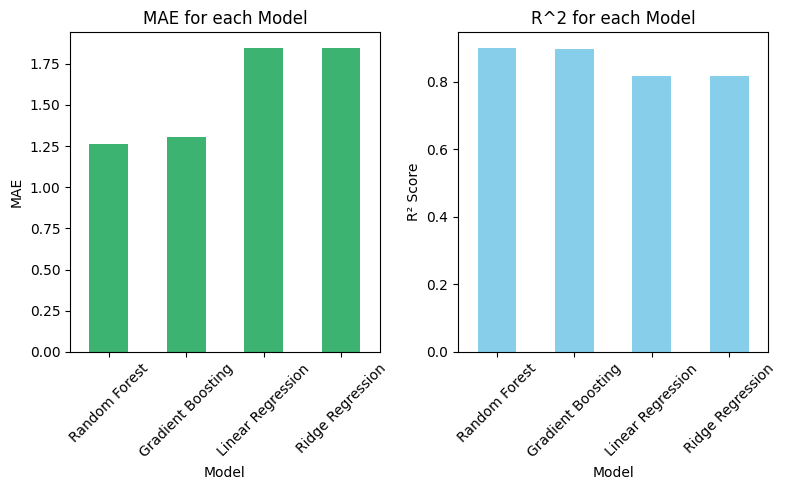

In [153]:
# plots comparing MAE and R^2 scores for each model
fig, axes = plt.subplots(1,2, figsize=(8,5))

# MAE graph
results['MAE'].sort_values().plot(kind = 'bar', ax = axes[0], color = 'mediumseagreen', title = 'MAE for each Model')
axes[0].set_ylabel("MAE")
axes[0].tick_params(axis="x", rotation=45)
axes[0].set_xlabel("Model")

# R^2 graph
results['R^2'].sort_values(ascending=False).plot(kind = 'bar', ax = axes[1], color = 'skyblue', title = 'R^2 for each Model')
axes[1].set_ylabel('R² Score')
axes[1].tick_params(axis="x", rotation=45)
axes[1].set_xlabel("Model")
plt.tight_layout()
plt.show()

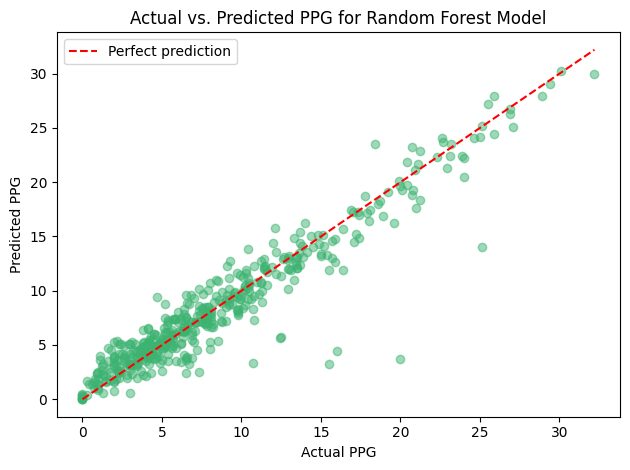

In [154]:
# visualizing actual PPG vs predicted PPG for the best model (Random Forest)
best_model = rf_model; best_preds = rf_preds; best_name = 'Random Forest'

# scatter plot
plt.scatter(y_test, best_preds, alpha=0.5, c = 'mediumseagreen')
plt.xlabel("Actual PPG")
plt.ylabel("Predicted PPG")
plt.title(f"Actual vs. Predicted PPG for {best_name} Model")

# perfect prediction line (closer to the line = better prediction)
max_val = max(y_test.max(), max(best_preds))
plt.plot([0, max_val], [0, max_val], "--r", label="Perfect prediction")
plt.legend()

plt.tight_layout(); plt.show()


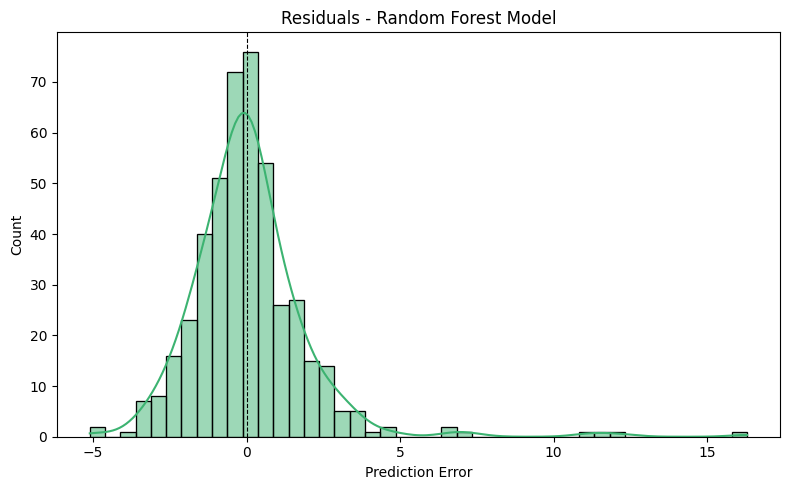

In [155]:
# residuals plot of Random Forest model
residuals = y_test - best_preds

plt.figure(figsize=(8,5))
sns.histplot(residuals, kde = True, color = 'mediumseagreen')
plt.axvline(x = 0, color = 'black', linewidth = 0.8, linestyle = '--')
plt.title(f"Residuals - {best_name} Model")
plt.xlabel("Prediction Error")
plt.tight_layout(); plt.show()

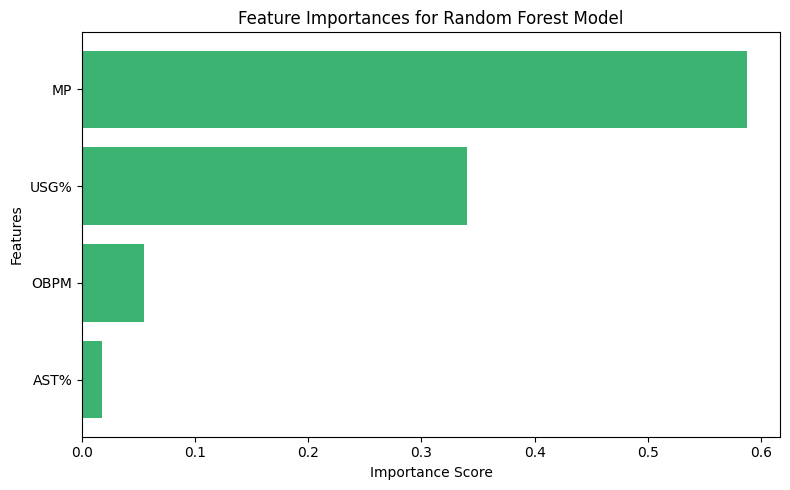

In [156]:
# Feature Importance Plot for Gradient Boosting Model
importances = pd.Series(best_model.feature_importances_, index = features).sort_values()

plt.figure(figsize=(8,5))
plt.barh(importances.index, importances.values, color ='mediumseagreen')
plt.title(f"Feature Importances for {best_name} Model"); plt.xlabel('Importance Score'); plt.ylabel('Features')
plt.tight_layout(); plt.show()

### Prediction Example with a real NBA player

In [157]:
# grab Anthony Edwards's stats for the most recent season
AE_last = player_data[player_data.Player == 'Anthony Edwards'].iloc[-1]

# extract features 
AE_features = pd.DataFrame([AE_last[features]])

# make a prediction
pred_PPG = best_model.predict(AE_features)[0]
actual_PPG = AE_last.PTS

print(f"Anthony Edwards")
print(f'Season: {int(AE_last.season)}')
print(f'Actual PPG: {actual_PPG:.1f}')
print(f'Predicted PPG: {pred_PPG:.1f}')
print(f'Error: {abs(actual_PPG-pred_PPG):.1f} PPG')

Anthony Edwards
Season: 2021
Actual PPG: 19.3
Predicted PPG: 19.0
Error: 0.3 PPG
